# set up

In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
    sys.path.append("D:/Github/MultiNeuronGLM")

In [2]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
sns.set_theme()

In [3]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [4]:
# Load LFP data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
#                    stimulus_condition_id=[246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258, 259, 260, 261, 
#                                           262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277,
#                                           278, 279, 280, 281, 282, 283, 284, 285, 286, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


# likelihood, stability as only history gets shorter

## Fit multiple

In [62]:
# Fit
penalty = 3e-1
tau = 10
order = 2
num_basis_baseline = 30
max_iter = 10
coupling_filter_params = {'peaks_max':10, 'num':6, 'nonlinear':0.3}
self_coupling_filter_params = {'peaks_max':10, 'num':6, 'nonlinear':0.3}

################ No need to change below
probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}
ROI_filter = {}
statistics_filter = {}
ROI_output = {}
statistics_output = {}
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        if i == j:
            model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **self_coupling_filter_params)
            continue
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
#     model.add_effect('refractory', target_probe, order=order, tau=tau, apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        running_filter[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        if i == j:
            model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **self_coupling_filter_params)
            continue
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params)
#     model.add_effect('refractory', target_probe, order=order, tau=tau,apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        stationary_filter[i,j] = filter_list[k]
        k += 1

6it [03:47, 37.86s/it]


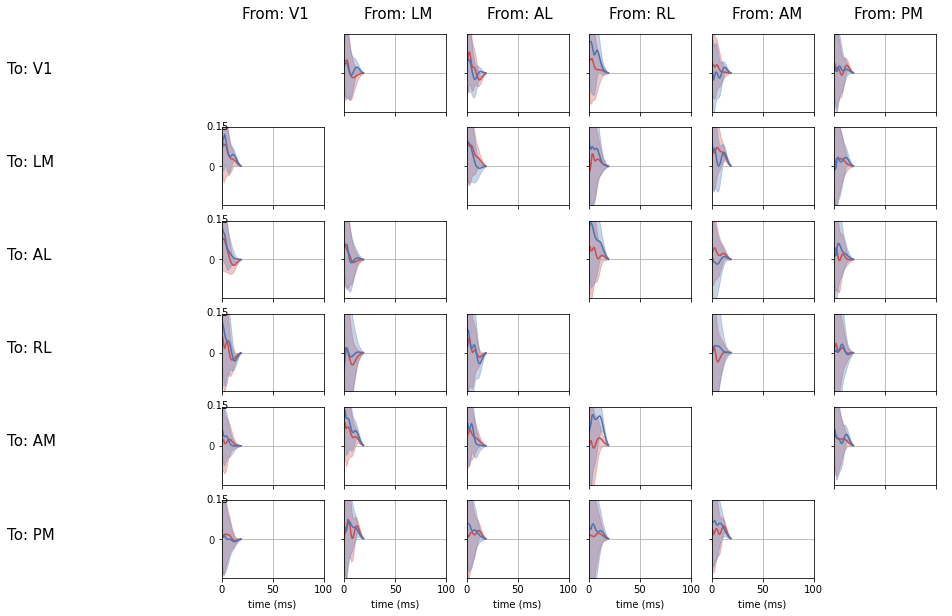

In [63]:
GLM.plot_filter_with_excursion(V1, stationary_filter, running_filter, inference=False, plot_baseline=False, 
                              plot_self=False)

In [64]:
MAX_FIRING_RATE = 3.5
# MAX_FIRING_RATE = np.log(np.array([0.70520469, 0.29707425, 1.10850376, 0.56863778, 1.64858215, -0.24620009])+0.3)
model_list = running_model_list
spikes_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
log_firing_rate_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
explosion_trial = 0

import copy
import numpy.random

for itrial in range(model_list[0].ntrial):
#     while True:
        nneuron = len(model_list)
        # Get three dimension matrix of coupling filters for better computing. 
        max_histories = 1
        nt = model_list[0].nt
        # allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
        allowed_effect_type = ['inhomogeneous_baseline', 'coupling', 'trial_coef']
        coupling_mat = np.zeros((max_histories, nneuron, nneuron))
        baseline_mat = np.zeros((nt, nneuron))
        spikes = np.zeros((nt, nneuron, 1))
        probe2num = {}
        for iprobe, probe in enumerate(probe_list):
            probe2num[probe] = iprobe

        for ineuron in range(nneuron):
            assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), "Only support inhomogeneous_baseline and coupling effects now!"
            model = model_list[ineuron]
            for ieffect, effect_type in enumerate(model.effect_type_list):

                if effect_type in ['inhomogeneous_baseline', ]:
                    baseline_mat[:, ineuron] = model.filters[ieffect]
                    baseline_mat[:, ineuron] = GLM.apply_warping_to_predictors(V1.time_line, 
                                                                               baseline_mat[:, ineuron][:,None], 
                                                                               model_list[0].shifts[itrial,:][None,:], 
                                                                               model_list[0].nt).squeeze()
                elif effect_type in ['coupling']:
                    nhistories = len(model.filters[ieffect])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories:
                        coupling_mat_old = coupling_mat
                        coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                        coupling_mat[-max_histories:, :, :] = coupling_mat_old
                        max_histories = nhistories
                    coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect])

        log_firing_rate = baseline_mat[:,:,np.newaxis]
        spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

        recent_spike_sum = spikes[0, :, 0]

        for t in range(1, nt):
            nhistories = min(t, max_histories)
            temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            log_firing_rate[t,:,0] += temp_log_firing_rate
            log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
            spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))

        log_firing_rate = log_firing_rate.squeeze()
        spikes = spikes.squeeze()
        
        if np.any(log_firing_rate==MAX_FIRING_RATE):
            explosion_trial += 1
            break
        else:
            spikes_rcd[:,:,itrial] = spikes
            log_firing_rate_rcd[:,:,itrial] = log_firing_rate
            break
            
print("running")
print(f"explosion trial percentage: {explosion_trial/model_list[0].ntrial}")

MAX_FIRING_RATE = 3.5
# MAX_FIRING_RATE = np.log(np.array([0.70520469, 0.29707425, 1.10850376, 0.56863778, 1.64858215, -0.24620009])+0.3)
model_list = stationary_model_list
spikes_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
log_firing_rate_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
explosion_trial = 0

import copy
import numpy.random

for itrial in range(model_list[0].ntrial):
    while True:
        nneuron = len(model_list)
        # Get three dimension matrix of coupling filters for better computing. 
        max_histories = 1
        nt = model_list[0].nt
        # allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
        allowed_effect_type = ['inhomogeneous_baseline', 'coupling', 'trial_coef']
        coupling_mat = np.zeros((max_histories, nneuron, nneuron))
        baseline_mat = np.zeros((nt, nneuron))
        spikes = np.zeros((nt, nneuron, 1))
        probe2num = {}
        for iprobe, probe in enumerate(probe_list):
            probe2num[probe] = iprobe

        for ineuron in range(nneuron):
            assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), "Only support inhomogeneous_baseline and coupling effects now!"
            model = model_list[ineuron]
            for ieffect, effect_type in enumerate(model.effect_type_list):

                if effect_type in ['inhomogeneous_baseline', ]:
                    baseline_mat[:, ineuron] = model.filters[ieffect]
                    baseline_mat[:, ineuron] = GLM.apply_warping_to_predictors(V1.time_line, 
                                                                               baseline_mat[:, ineuron][:,None], 
                                                                               model_list[0].shifts[itrial,:][None,:], 
                                                                               model_list[0].nt).squeeze()
                elif effect_type in ['coupling']:
                    nhistories = len(model.filters[ieffect])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories:
                        coupling_mat_old = coupling_mat
                        coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                        coupling_mat[-max_histories:, :, :] = coupling_mat_old
                        max_histories = nhistories
                    coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect])

        log_firing_rate = baseline_mat[:,:,np.newaxis]
        spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

        recent_spike_sum = spikes[0, :, 0]

        for t in range(1, nt):
            nhistories = min(t, max_histories)
            temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            log_firing_rate[t,:,0] += temp_log_firing_rate
            log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
            spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))

        log_firing_rate = log_firing_rate.squeeze()
        spikes = spikes.squeeze()
        
        if np.any(log_firing_rate==MAX_FIRING_RATE):
            explosion_trial += 1
            break
        else:
            spikes_rcd[:,:,itrial] = spikes
            log_firing_rate_rcd[:,:,itrial] = log_firing_rate
            break

print("stationary")
print(f"explosion trial percentage: {explosion_trial/model_list[0].ntrial}")
total_nll = sum([running_model_list[i].aic for i in range(6)]) + sum([stationary_model_list[i].aic for i in range(6)])

print(f"likelihood: {total_nll}")


running
explosion trial percentage: 0.0
stationary
explosion trial percentage: 0.5116279069767442
likelihood: 286974.19298072957


@ coupling, history

@ 20, 20
running
explosion trial percentage: 0.48148148148148145
stationary
explosion trial percentage: 1.3565891472868217
likelihood: 286259.99453823874



# Trial-wise inhomogeneous baseline

In [67]:
penalty = 3e-1
tau = 10
order = 2
num_basis_baseline = 20
max_iter = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}

################ No need to change below
probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}

running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('trialwise_inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        if i == j:
            model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **self_coupling_filter_params)
            continue
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
#     model.add_effect('refractory', target_probe, order=order, tau=tau, apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit(target_probe, verbose=False, penalty=penalty)
    running_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        running_filter[i,j] = filter_list[k]
        k += 1
    filter_list = model.get_filter_output(ci=True)
    running_output[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        running_output[i,j] = filter_list[k]
        k += 1
    
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('trialwise_inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params)
#     model.add_effect('refractory', target_probe, order=order, tau=tau,apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit(target_probe, verbose=False, penalty=penalty)
    stationary_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        stationary_filter[i,j] = filter_list[k]
        k += 1
    filter_list = model.get_filter_output(ci=True)
    stationary_output[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        stationary_output[i,j] = filter_list[k]
        k += 1

0it [00:00, ?it/s]/home/qix/MultiNeuronGLM/GLM.py:1283: RuntimeWarning: overflow encountered in exp
  nll += np.exp(log_lmbd)
/home/qix/MultiNeuronGLM/GLM.py:1388: RuntimeWarning: invalid value encountered in sqrt
  bse = np.sqrt(np.diag(np.linalg.inv(hessian)))
1it [02:30, 150.62s/it]/home/qix/MultiNeuronGLM/GLM.py:1283: RuntimeWarning: overflow encountered in exp
  nll += np.exp(log_lmbd)
1it [05:29, 329.15s/it]


LinAlgError: Singular matrix

In [ ]:
GLM.plot_filter_with_excursion(V1, stationary_filter, running_filter, inference=False, plot_baseline=False, 
                              plot_self=False)

In [64]:
MAX_FIRING_RATE = 3.5
# MAX_FIRING_RATE = np.log(np.array([0.70520469, 0.29707425, 1.10850376, 0.56863778, 1.64858215, -0.24620009])+0.3)
model_list = running_model_list
spikes_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
log_firing_rate_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
explosion_trial = 0

import copy
import numpy.random

for itrial in range(model_list[0].ntrial):
#     while True:
        nneuron = len(model_list)
        # Get three dimension matrix of coupling filters for better computing. 
        max_histories = 1
        nt = model_list[0].nt
        # allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
        allowed_effect_type = ['trialwise_inhomogeneous_baseline', 'coupling', 'trial_coef']
        coupling_mat = np.zeros((max_histories, nneuron, nneuron))
        baseline_mat = np.zeros((nt, nneuron))
        spikes = np.zeros((nt, nneuron, 1))
        probe2num = {}
        for iprobe, probe in enumerate(probe_list):
            probe2num[probe] = iprobe

        for ineuron in range(nneuron):
            assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), "Only support inhomogeneous_baseline and coupling effects now!"
            model = model_list[ineuron]
            for ieffect, effect_type in enumerate(model.effect_type_list):

                if effect_type in ['trialwise_inhomogeneous_baseline', ]:
                    baseline_mat[:, ineuron] = model.filters[ieffect]

                elif effect_type in ['coupling']:
                    nhistories = len(model.filters[ieffect])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories:
                        coupling_mat_old = coupling_mat
                        coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                        coupling_mat[-max_histories:, :, :] = coupling_mat_old
                        max_histories = nhistories
                    coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect])

        log_firing_rate = baseline_mat[:,:,np.newaxis]
        spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

        recent_spike_sum = spikes[0, :, 0]

        for t in range(1, nt):
            nhistories = min(t, max_histories)
            temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            log_firing_rate[t,:,0] += temp_log_firing_rate
            log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
            spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))

        log_firing_rate = log_firing_rate.squeeze()
        spikes = spikes.squeeze()
        
        if np.any(log_firing_rate==MAX_FIRING_RATE):
            explosion_trial += 1
            break
        else:
            spikes_rcd[:,:,itrial] = spikes
            log_firing_rate_rcd[:,:,itrial] = log_firing_rate
            break
            
print("running")
print(f"explosion trial percentage: {explosion_trial/model_list[0].ntrial}")

MAX_FIRING_RATE = 3.5
# MAX_FIRING_RATE = np.log(np.array([0.70520469, 0.29707425, 1.10850376, 0.56863778, 1.64858215, -0.24620009])+0.3)
model_list = stationary_model_list
spikes_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
log_firing_rate_rcd = np.zeros((model_list[0].nt, 6, model_list[0].ntrial))
explosion_trial = 0

import copy
import numpy.random

for itrial in range(model_list[0].ntrial):
    while True:
        nneuron = len(model_list)
        # Get three dimension matrix of coupling filters for better computing. 
        max_histories = 1
        nt = model_list[0].nt
        # allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
        allowed_effect_type = ['trialwise_inhomogeneous_baseline', 'coupling', 'trial_coef']
        coupling_mat = np.zeros((max_histories, nneuron, nneuron))
        baseline_mat = np.zeros((nt, nneuron))
        spikes = np.zeros((nt, nneuron, 1))
        probe2num = {}
        for iprobe, probe in enumerate(probe_list):
            probe2num[probe] = iprobe

        for ineuron in range(nneuron):
            assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), "Only support inhomogeneous_baseline and coupling effects now!"
            model = model_list[ineuron]
            for ieffect, effect_type in enumerate(model.effect_type_list):

                if effect_type in ['trialwise_inhomogeneous_baseline', ]:
                    baseline_mat[:, ineuron] = model.filters[ieffect]
                    baseline_mat[:, ineuron] = GLM.apply_warping_to_predictors(V1.time_line, 
                                                                               baseline_mat[:, ineuron][:,None], 
                                                                               model_list[0].shifts[itrial,:][None,:], 
                                                                               model_list[0].nt).squeeze()
                elif effect_type in ['coupling']:
                    nhistories = len(model.filters[ieffect])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories:
                        coupling_mat_old = coupling_mat
                        coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                        coupling_mat[-max_histories:, :, :] = coupling_mat_old
                        max_histories = nhistories
                    coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect])

        log_firing_rate = baseline_mat[:,:,np.newaxis]
        spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

        recent_spike_sum = spikes[0, :, 0]

        for t in range(1, nt):
            nhistories = min(t, max_histories)
            temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            log_firing_rate[t,:,0] += temp_log_firing_rate
            log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
            spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))

        log_firing_rate = log_firing_rate.squeeze()
        spikes = spikes.squeeze()
        
        if np.any(log_firing_rate==MAX_FIRING_RATE):
            explosion_trial += 1
            break
        else:
            spikes_rcd[:,:,itrial] = spikes
            log_firing_rate_rcd[:,:,itrial] = log_firing_rate
            break

print("stationary")
print(f"explosion trial percentage: {explosion_trial/model_list[0].ntrial}")
total_nll = sum([running_model_list[i].aic for i in range(6)]) + sum([stationary_model_list[i].aic for i in range(6)])

print(f"likelihood: {total_nll}")


running
explosion trial percentage: 0.0
stationary
explosion trial percentage: 0.5116279069767442
likelihood: 286974.19298072957
